In [13]:
import torch 
import matplotlib.pyplot as plt
import random
import numpy as np
from matplotlib.colors import ListedColormap
import dill
from sparse_generalization.envs.box_world.env import BoxWorldEnv
from sparse_generalization.envs.box_world.wrappers import make_env
from minigrid.wrappers import FullyObsWrapper
import gymnasium as gym
import cv2
import matplotlib.pyplot as plt
from torchmetrics.classification.accuracy import BinaryAccuracy
gym.register('BoxWorldEnv-v1', BoxWorldEnv)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
with open('../results/bern_mha_20seeds_24_Feb_2026__06h27m.pl', 'rb') as file:
    results = dill.load(file)

In [47]:
A = torch.eye(100) 
num_rand = 1

for _ in range(4):
    I = torch.eye(100) * 4
    indices = torch.randint(low=0, high=100, size=(2*num_rand,)).reshape(2, num_rand)
    print(indices)
    A[indices[0], indices[1]] = 1
    A = A @ I
    
A.sum()

tensor([[26],
        [43]])
tensor([[19],
        [ 5]])
tensor([[59],
        [60]])
tensor([[78],
        [22]])


tensor(25940.)

In [25]:
with open('../data/box_world/balanced_dist_500.pl', 'rb') as file:
    dataset = dill.load(file)
    file.close()

In [26]:
x_train = dataset['X_train']
y_train = dataset['Y_train']
x_test_ind = dataset['X_test_ind']
y_test_ind = dataset['Y_test_ind']
x_test_ood = dataset['X_test_ood']
y_test_ood = dataset['Y_test_ood']
edges_train = dataset['edges_train']
edges_test = dataset['edges_test_ood']

In [195]:
test = edges_train[0:50]
test = test.view(50 * 1 * 4, 2, 2)
test = test[:, :, 1] * 10 + test[:, :, 0] 
test = test.view(50, 4, 2)
A = torch.zeros(50, 100, 100)
item = test[0]
A[0, item[:, 0], item[:, 1]] = 1

In [190]:
test[0]

tensor([[[16, 54],
         [11, 12],
         [51, 52],
         [27, 26]]])

In [203]:
edges_train[3]

tensor([[[[6, 7],
          [5, 8]],

         [[4, 6],
          [5, 6]],

         [[1, 7],
          [2, 7]],

         [[8, 5],
          [7, 5]]]])

In [145]:
def get_edges(obs, residual=False):
    edges = []
    # get goal-lock 
    x_goal, y_goal = torch.where(obs[:, :, 0] == 8)
    goal = torch.stack([x_goal, y_goal], dim=1).squeeze()
    edges.append(((goal[0]+1, goal[1]), (goal[0], goal[1])))
    # for each key check key + 1 in lock then a combo
    xs, ys = torch.where(x_train[0][:, :, 0] == 13)
    locks = torch.stack([xs, ys], dim=1)
    locks = locks[~(locks == torch.tensor([goal[0]+1, goal[1]])).all(dim=1)]
    
    xs, ys = torch.where(x_train[0][:, :, 0] == 12)
    keys = torch.stack([xs, ys], dim=1)
    for lock in locks:
        key = (lock[0]-1, lock[1])
        edges.append(((lock[0], lock[1]), (key)))
        keys = keys[~(keys == torch.tensor([lock[0]-1, lock[1]])).all(dim=1)]
        
    # remaining key is residual or looking from agent
    first_key = keys.squeeze()
    if not residual: 
        xs, ys = torch.where(x_train[0][:, :, 0] == 10)
        agent = torch.stack([xs, ys], dim=1).squeeze()
        edges.append(((agent[0], agent[1]), (first_key[0], first_key[1])))
    
    return edges

In [43]:
from sparse_generalization.layers.oracle import MultiHeadAttentionOracle

mha = MultiHeadAttentionOracle(embed_size=3, num_heads=3)
x_train = x_train.view(500, 100, 3).float()
mha(x_train, x_train, x_train, edges_train)[1].shape

torch.Size([500, 100, 100])

Generating Class 0 samples...
Generating Class 1 samples...

Dataset generated successfully with num_embeddings=16!
X shape: torch.Size([5000, 4, 4, 16]) | Y shape: torch.Size([5000, 1])
Verify unique values per grid sample: 2 values (should be 16)
SPARTAN model successfully instantiated and pushed to device.
Starting training loop for 2000 epochs...


Epoch: 2000: 100%|██████████| 2000/2000 [12:48<00:00,  2.60it/s, loss=2.61e-6, acc=1, sparse_loss=1.54e-5, mask_edges=27.2, attn_edges=10.8]     


Model max paths: 272.0
--- Matrix Shape Summary ---
Layer 1 -> Attn: [1, 16, 16] | Mask Attn: [1, 16, 16] | Mask: [1, 16, 16]
Aggregation Layer -> Attn: [1, 1, 16] | Mask Attn: [1, 1, 1, 16] | Mask: [1, 1, 16]
Final Compiled Path Mask Shape: [1, 1, 16]



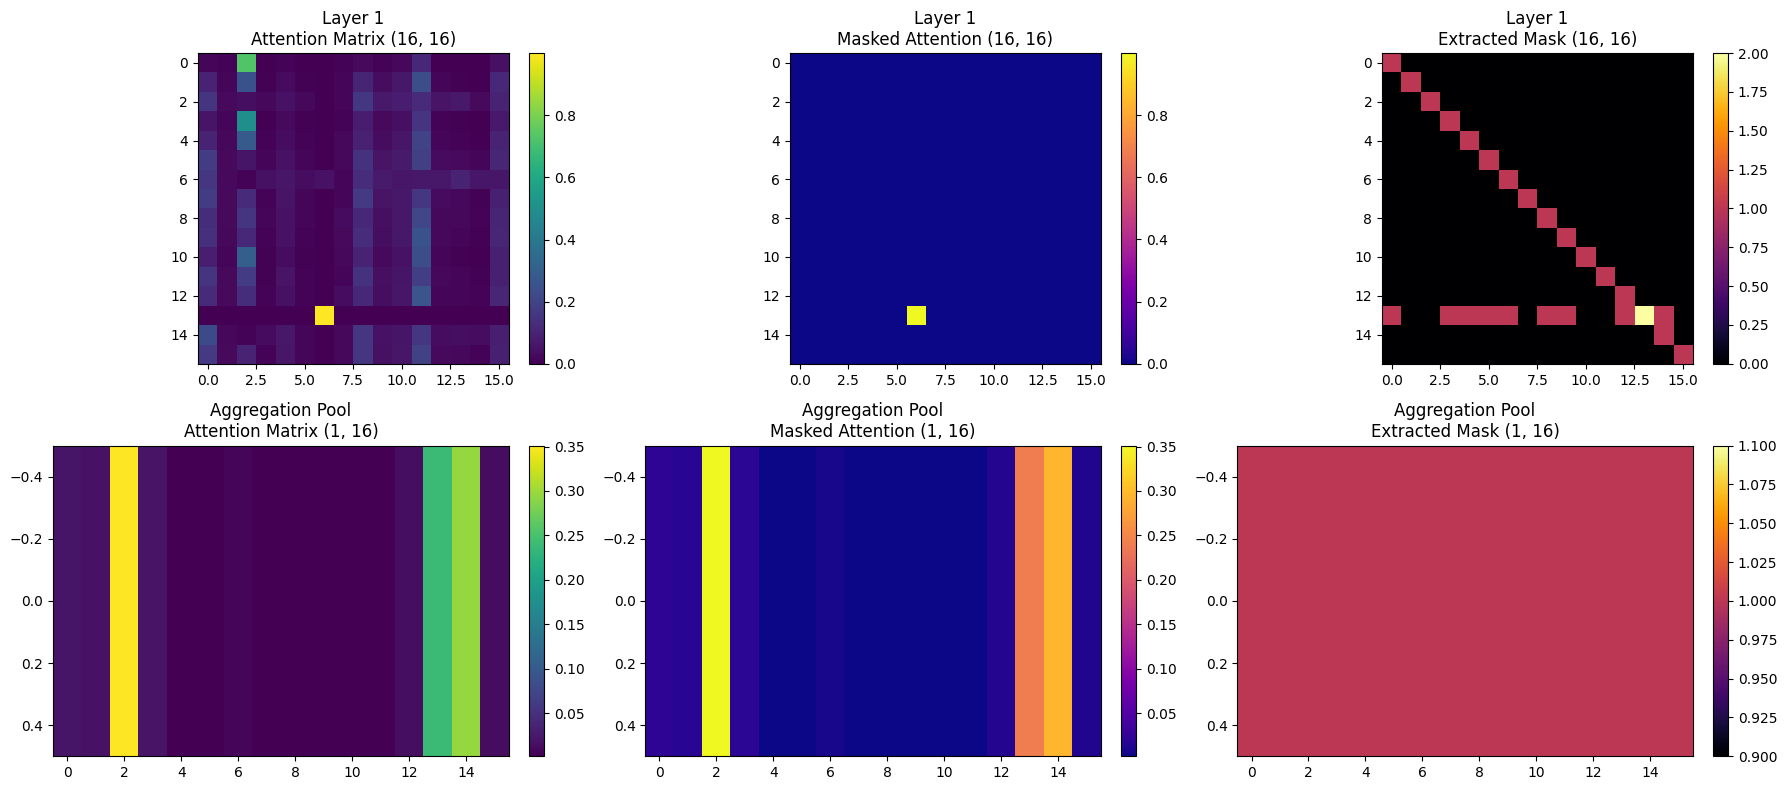

=== Softmax Sum Evaluation (Tolerance = 1e-4) ===

[Layer 1] Matrix Shape: [16, 16]
  -> Rows sum to 1.0? False (Min sum: 0.0000, Max sum: 1.0080)
  -> Cols sum to 1.0? False (Min sum: 0.0000, Max sum: 0.9990)

[Aggregation Pool] Matrix Shape: [1, 16]
  -> Rows sum to 1.0? True (Min sum: 1.0000, Max sum: 1.0000)
  -> Cols sum to 1.0? False (Min sum: 0.0016, Max sum: 0.3510)


In [9]:
# %% [markdown]
# # SPARTAN Model Training and Sparsity Analysis Notebook

# %%
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Import your SPARTAN class directly from your script file
from sparse_generalization.models.spartan import SPARTAN

import random
import numpy as np

def seed_everything(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if you use multi-GPU
    
    # Ensure deterministic behavior in CuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Execute the seed setting
seed_everything(9)

# Ensure graphics render inline
%matplotlib inline

# %% [markdown]
# ## 1. Synthetic Dataset Generation (Strict Permutations, Pool Size = 16)

# %%
device = "cuda" if torch.cuda.is_available() else "cpu"

class Logger:
    def __init__(self):
        pass

    def log_metrics(self, a, step):
        pass

# Dimensions setup - Strictly bounded pool
width, height, channels = 4, 4, 1
num_embeddings = width * height  # Exactly 16 unique tokens available (0 to 15)
num_samples = 5000  

X_list = []
Y_list = []

half_samples = num_samples // 2

def check_row_rule(grid):
    """Helper to verify if a 4x4 grid meets the Class 1 criteria."""
    for row_idx in range(width):
        row = grid[row_idx]
        if (0 in row and 1 in row) or (8 in row and 9 in row):
            return True
    return False

# --- 1. Generate Class 0 Samples (No rules allowed, strict permutations of 0-15) ---
print("Generating Class 0 samples...")
while len(X_list) < half_samples:
    # Generate a perfect permutation of numbers 0 to 15
    grid = torch.randperm(num_embeddings).float().view(width, height)
    
    # Discard if it accidentally satisfies the row rule
    if not check_row_rule(grid):
        X_list.append(grid.unsqueeze(-1))
        Y_list.append(torch.tensor([0.0]))

# --- 2. Generate Class 1 Samples (Forced rules, strict permutations of 0-15) ---
print("Generating Class 1 samples...")
while len(X_list) < num_samples:
    # 1. Pick which rule pair to force inject
    target_pair = torch.rand(1).item()
    injected_tokens = [0.0, 1.0] if target_pair > 0.5 else [8.0, 9.0]
    
    # 2. Get the remaining 14 tokens in the 0-15 range to maintain unique cells
    forbidden = set(injected_tokens)
    remaining_pool = torch.tensor([float(x) for x in range(num_embeddings) if x not in forbidden], dtype=torch.float32)
    
    # Shuffle the background tokens
    background_tokens = remaining_pool[torch.randperm(len(remaining_pool))]
    
    # 3. Create a flat grid array
    flat_grid = torch.zeros(num_embeddings)
    
    # Randomly pick a target row, and 2 unique column positions within that row
    target_row = torch.randint(0, width, (1,)).item()
    col_indices = torch.randperm(height)[:2]
    
    # Map 2D coordinates to flat 1D indices
    idx1 = target_row * height + col_indices[0]
    idx2 = target_row * height + col_indices[1]
    
    # Inject the rule pair
    flat_grid[idx1] = injected_tokens[0]
    flat_grid[idx2] = injected_tokens[1]
    
    # Fill the remaining 14 slots with the rest of the 0-15 numbers
    bg_idx = 0
    for i in range(num_embeddings):
        if i != idx1 and i != idx2:
            flat_grid[i] = background_tokens[bg_idx]
            bg_idx += 1
            
    # Reshape back to 4x4 matrix
    grid = flat_grid.view(width, height)
    
    X_list.append(grid.unsqueeze(-1))
    Y_list.append(torch.tensor([1.0]))

# Stack and consolidate
X_data = torch.stack(X_list)
Y_data = torch.stack(Y_list)

X_data = torch.nn.functional.one_hot(X_data.long(), num_classes=num_embeddings).squeeze().float()

# Shuffle the final collection to mix classes
shuffle_idx = torch.randperm(num_samples)
X_data = X_data[shuffle_idx]
Y_data = Y_data[shuffle_idx]

dataset = TensorDataset(X_data, Y_data)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

print(f"\nDataset generated successfully with num_embeddings={num_embeddings}!")
print(f"X shape: {X_data.shape} | Y shape: {Y_data.shape}")
print(f"Verify unique values per grid sample: {len(torch.unique(X_data[0]))} values (should be 16)")


# %% [markdown]
# ## 2. Instantiating the SPARTAN Object
# %%
logger = Logger()

model = SPARTAN(
    inp_dim=num_embeddings,
    out_dim=1,
    model_dim=32,
    alpha=0.1, 
    num_layers=1,
    num_heads=1,
    include_sparsity=True,   # Standard sparsity enforcement
    lagrangian=False,    
    pe=True, 
    sinusoidal=True,     
    embedding_inp=False,
    separate_mask=False, 
    agg_pool=True,            # Output pool collapses sequence dim
    num_embeddings=num_embeddings,
    beta1=0.99, 
    device=device,
    logger=logger
).to(device)

print("SPARTAN model successfully instantiated and pushed to device.")

# %% [markdown]
# ## 3. Model Training
# %%
epochs = 2000
print(f"Starting training loop for {epochs} epochs...")

# Unpacking the 9 elements returned by your fit method
losses, accs, sparses, _, _, _, _, _, _ = model.fit(dataloader, num_epochs=epochs, testloaders=[])
print(f"Model max paths: {model.max_paths}")

# %% [markdown]
# ## 4. Extracting Internal Attention and Sparsity States
# %%
model.eval()
sample_x, _ = next(iter(dataloader))
sample_x = sample_x[:1].to(device) # Isolate a single sample

with torch.no_grad():
    # Unpacking all 5 outputs returned by your latest forward pass definition
    out, final_path, mask_attns, attns, masks = model(sample_x)

print("--- Matrix Shape Summary ---")
for i in range(len(attns)):
    is_agg = (i == len(attns) - 1 and model.agg_pool)
    name = f"Layer {i+1}" if not is_agg else "Aggregation Layer"
    print(f"{name} -> Attn: {list(attns[i].shape)} | Mask Attn: {list(mask_attns[i].shape)} | Mask: {list(masks[i].shape)}")

print(f"Final Compiled Path Mask Shape: {list(final_path.shape)}\n")

# %% [markdown]
# ## 5. Visualizing Attentions, Masked Attentions, and Masks Layer-by-Layer
# This handles explicit vector squeezing for (1, 1, 16) or (1, 16) dimensions in the aggregation tier.

# %%
num_plots = len(attns)
# 3 Columns: [Attention] | [Masked Attention] | [Extracted Mask]
fig, axes = plt.subplots(num_plots, 3, figsize=(18, 4.0 * num_plots))

# Handle single-layer array boundary edge cases for matplotlib stability
if num_plots == 1:
    axes = [axes]

for idx in range(num_plots):
    is_agg = (idx == num_plots - 1 and model.agg_pool)
    layer_name = f"Layer {idx+1}" if not is_agg else "Aggregation Pool"
    
    # Isolate first item in the batch and completely squeeze out extra dummy/head dims
    # Normal layer: (B=1, H=1, 16, 16) -> (16, 16)
    # Agg layer with explicit heads: (B=1, H=1, 1, 16) or (B=1, 1, 16) -> (1, 16)
    attn_img = attns[idx][0].squeeze().cpu().numpy()
    mask_attn_img = mask_attns[idx][0].squeeze().cpu().numpy()
    mask_img = masks[idx][0].squeeze().cpu().numpy()
    
    # If the vector squished to a purely 1D numpy array shape like (16,), expand to (1, 16) for imshow
    if attn_img.ndim == 1:
        attn_img = attn_img[None, :]
        mask_attn_img = mask_attn_img[None, :]
        mask_img = mask_img[None, :]

    # Dynamically pick display mode for 2D vs 1D tracking rows
    is_flat_shape = attn_img.shape[0] == 1
    aspect_mode = 'auto' if is_flat_shape else 'equal'
    interp_mode = 'nearest' if is_flat_shape else None

    # -------------------------------------
    # Column 1: Raw Attention Map
    # -------------------------------------
    ax_attn = axes[idx][0]
    im1 = ax_attn.imshow(attn_img, cmap='viridis', aspect=aspect_mode, interpolation=interp_mode)
    ax_attn.set_title(f"{layer_name}\nAttention Matrix {attn_img.shape}")
    fig.colorbar(im1, ax=ax_attn, fraction=0.046, pad=0.04)
    
    # -------------------------------------
    # Column 2: Masked Attention Map
    # -------------------------------------
    ax_m_attn = axes[idx][1]
    im2 = ax_m_attn.imshow(mask_attn_img, cmap='plasma', aspect=aspect_mode, interpolation=interp_mode)
    ax_m_attn.set_title(f"{layer_name}\nMasked Attention {mask_attn_img.shape}")
    fig.colorbar(im2, ax=ax_m_attn, fraction=0.046, pad=0.04)
    
    # -------------------------------------
    # Column 3: Sparsity Selection Mask
    # -------------------------------------
    ax_mask = axes[idx][2]
    im3 = ax_mask.imshow(mask_img, cmap='inferno', aspect=aspect_mode, interpolation=interp_mode)
    ax_mask.set_title(f"{layer_name}\nExtracted Mask {mask_img.shape}")
    fig.colorbar(im3, ax=ax_mask, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 6. Softmax Axis and Sum Verification

# %%
print("=== Softmax Sum Evaluation (Tolerance = 1e-4) ===")

for idx, attn_tensor in enumerate(mask_attns):
    is_agg = (idx == len(mask_attns) - 1 and model.agg_pool)
    layer_name = f"Layer {idx+1}" if not is_agg else "Aggregation Pool"
    
    # Target element 0 and strip out batch/head dims for numerical profiling
    matrix = attn_tensor[0].squeeze()
    if matrix.ndim == 1:
        matrix = matrix[None, :] # map to shape (1, 16)
        
    row_sums = matrix.sum(dim=-1)
    col_sums = matrix.sum(dim=-2)
    
    rows_match = torch.allclose(row_sums, torch.ones_like(row_sums), atol=1e-4)
    cols_match = torch.allclose(col_sums, torch.ones_like(col_sums), atol=1e-4)
    
    print(f"\n[{layer_name}] Matrix Shape: {list(matrix.shape)}")
    print(f"  -> Rows sum to 1.0? {rows_match} (Min sum: {row_sums.min().item():.4f}, Max sum: {row_sums.max().item():.4f})")
    print(f"  -> Cols sum to 1.0? {cols_match} (Min sum: {col_sums.min().item():.4f}, Max sum: {col_sums.max().item():.4f})")

In [4]:
import torch
import random
import numpy as np
import lightning as pl
from torch.utils.data import TensorDataset, DataLoader

# Ensure the TransformerLit and utilities are importable in your workspace
from sparse_generalization.models.transformer import TransformerLit
from sparse_generalization.models.spartan import SPARTAN

def seed_everything(seed=9):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(9)

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- 1. CONFIGURATION ---
width, height, channels = 4, 4, 1
num_embeddings = width * height  # 16 unique tokens
num_samples = 5000  
batch_size = 256

X_list = []
Y_list = []
half_samples = num_samples // 2

def check_row_rule(grid):
    """Verifies if a 4x4 grid meets the target sequence matching condition."""
    for row_idx in range(width):
        row = grid[row_idx]
        if (0 in row and 1 in row) or (8 in row and 9 in row):
            return True
    return False

# --- 2. DATA GENERATION ---
print("Generating Data Samples...")

# Class 0: No rule satisfaction allowed
while len(X_list) < half_samples:
    grid = torch.randperm(num_embeddings).float().view(width, height)
    if not check_row_rule(grid):
        X_list.append(grid.unsqueeze(-1))  # Shape: (4, 4, 1)
        Y_list.append(torch.tensor([0.0])) # Binary label float32 for BCEWithLogitsLoss

# Class 1: Force inject criteria pairs
while len(X_list) < num_samples:
    target_pair = torch.rand(1).item()
    injected_tokens = [0.0, 1.0] if target_pair > 0.5 else [8.0, 9.0]
    
    forbidden = set(injected_tokens)
    remaining_pool = torch.tensor([float(x) for x in range(num_embeddings) if x not in forbidden], dtype=torch.float32)
    background_tokens = remaining_pool[torch.randperm(len(remaining_pool))]
    
    flat_grid = torch.zeros(num_embeddings)
    target_row = torch.randint(0, width, (1,)).item()
    col_indices = torch.randperm(height)[:2]
    
    idx1 = target_row * height + col_indices[0]
    idx2 = target_row * height + col_indices[1]
    
    flat_grid[idx1] = injected_tokens[0]
    flat_grid[idx2] = injected_tokens[1]
    
    bg_idx = 0
    for i in range(num_embeddings):
        if i != idx1 and i != idx2:
            flat_grid[i] = background_tokens[bg_idx]
            bg_idx += 1
            
    grid = flat_grid.view(width, height)
    X_list.append(grid.unsqueeze(-1))  # Shape: (4, 4, 1)
    Y_list.append(torch.tensor([1.0]))

# Convert arrays into structured Tensors
X_data = torch.stack(X_list)  # (5000, 4, 4, 1)
Y_data = torch.stack(Y_list)  # (5000, 1)

X_data = torch.nn.functional.one_hot(X_data.long(), num_classes=num_embeddings).squeeze().float()

# Shuffle Dataset
shuffle_idx = torch.randperm(num_samples)
X_data = X_data[shuffle_idx]
Y_data = Y_data[shuffle_idx]

dataset = TensorDataset(X_data, Y_data)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"Dataset compiled. X shape: {X_data.shape} | Y shape: {Y_data.shape}")

# --- 3. MODEL INSTANTIATION ---
# Map configuration parameters matching TransformerLit constructor attributes
val_to_name = {0: "id"}

import torch
from copy import deepcopy

# Assuming both models are imported or defined in your runtime environment:
# from sparse_generalization.models.spartan import SPARTAN
# from sparse_generalization.models.transformer_lit import TransformerLit

def copy_spartan_to_transformer(spartan_model, transformer_model):
    """
    Copies identical layer parameters from a SPARTAN instance 
    to a TransformerLit instance to ensure exact initialization parity.
    """
    print("--- Starting Parameter Copy Loop ---")
        
    # 2. Copy Feature Map Preprocessing Blocks
    # Note: Ensure both models have matching dimensions for this to pass safely!
    try:
        transformer_model.feature_map.load_state_dict(spartan_model.feature_map.state_dict())
        print("✓ Successfully copied: feature_map bottleneck layers")
    except RuntimeError as e:
        print(f"✗ Failed to copy feature_map due to structural mismatch: {e}")
        print("  (Check if your TransformerLit feature_map input is still set to 4 * model_dim)")

    # 3. Copy Attention Blocks Layer-by-Layer
    # We iterate through the ModuleLists and map linear weights across their custom implementations
    num_layers = min(len(spartan_model.layers), len(transformer_model.layers))
    for i in range(num_layers):
        spartan_layer = spartan_model.layers[i]
        trans_layer = transformer_model.layers[i]
        
        print(f"\nProcessing Attention Block Layer {i+1}...")
        
        # Mapping Q, K, V Projections
        # SPARTAN maps queries via self.queries, keys via self.keys, etc.
        # Adjust these target attributes if your sub-blocks nest them differently
        try:
            if hasattr(spartan_layer, 'queries') and hasattr(trans_layer, 'queries'):
                trans_layer.queries.load_state_dict(spartan_layer.queries.state_dict())
                trans_layer.keys.load_state_dict(spartan_layer.keys.state_dict())
                trans_layer.values.load_state_dict(spartan_layer.values.state_dict())
                trans_layer.projection.load_state_dict(spartan_layer.projection.state_dict())
                print(f"  ✓ Copied Core Attention Projections (Q, K, V, Out-Proj)")
            elif hasattr(trans_layer, 'mha_layer'):
                # If TransformerLit uses native nn.MultiheadAttention, we extract weights manually
                # (e.g., packing individual Q,K,V weights into in_proj_weight)
                q_w = spartan_layer.queries.weight.data
                k_w = spartan_layer.keys.weight.data
                v_w = spartan_layer.values.weight.data
                
                # Combine into unified MultiheadAttention layout: [Q_w, K_w, V_w]
                combined_in_proj = torch.cat([q_w, k_w, v_w], dim=0)
                trans_layer.mha_layer.in_proj_weight.data.copy_(combined_in_proj)
                
                if spartan_layer.queries.bias is not None:
                    q_b = spartan_layer.queries.bias.data
                    k_b = spartan_layer.keys.bias.data
                    v_b = spartan_layer.values.bias.data
                    combined_in_bias = torch.cat([q_b, k_b, v_b], dim=0)
                    trans_layer.mha_layer.in_proj_bias.data.copy_(combined_in_bias)
                
                # Copy out projection
                trans_layer.mha_layer.out_proj.weight.data.copy_(spartan_layer.projection.weight.data)
                print(f"  ✓ Packed separate SPARTAN weights into unified native nn.MultiheadAttention layer")
        except Exception as e:
            print(f"  ✗ Layer mapping warning: {e}")

    # 4. Copy Head Classifier Output Layer
    print("")
    if hasattr(spartan_model, 'out') and hasattr(transformer_model, 'out'):
        # Only copy if structural pool techniques match (e.g., both Linear or AggregationAttention)
        try:
            transformer_model.out.load_state_dict(spartan_model.out.state_dict())
            print("✓ Successfully copied: Head Prediction/Pooling layer ('out')")
        except RuntimeError:
            print("✗ Could not match classification heads (check if pool techniques match between models)")

    # 5. Copy Token Pool CLS token parameter if active
    if hasattr(spartan_model, 'cls') and hasattr(transformer_model, 'cls'):
        transformer_model.cls.data.copy_(spartan_model.cls.data)
        print("✓ Successfully copied: CLS token parameter token_pool")

    print("\n--- Parameter Synchronization Finalized ---")
    return transformer_model


# --- APPLICATION EXECUTION PIPELINE ---
device = "cuda" if torch.cuda.is_available() else "cpu"
num_embeddings = 16
model_dim = 32

# Initialize your baseline SPARTAN object
spartan_instance = SPARTAN(
    inp_dim=num_embeddings,
    out_dim=1,
    model_dim=model_dim,
    num_layers=1,
    device='cpu',
    num_embeddings=num_embeddings,
    embedding_inp=True,
    agg_pool=True,
    include_sparsity=False
).to(device)

# Initialize your baseline TransformerLit object 
# CRITICAL: We update input_dim constraint match fixes from earlier debug steps
transformer_instance = TransformerLit(
    inp_dim=num_embeddings,
    model_dim=model_dim,
    out_dim=1,
    num_layers=1,
    num_embeddings=num_embeddings,
    embedding_inp=False,
    positional_encoding=True, 
    sinusoidal=False,
    agg_pool=True,
    include_sparsity=False, 
).to(device)

# Execute Copy
transformer_instance = copy_spartan_to_transformer(spartan_instance, transformer_instance)

# Inject execution tracking bounds used inside your logging routines
transformer_instance.num_train_batches = len(dataloader)
transformer_instance.num_val_batches = 1

print("TransformerLit model configured successfully.")

# --- 4. ENGINE TRAINING VIA LIGHTNING TRAINER ---
# TransformerLit specifies self.automatic_optimization = False, 
# requiring a workflow configured to support manual backpropagation loops.
trainer = pl.Trainer(
    max_epochs=2000,               # Adjusted lower for continuous integration stability
    accelerator="auto",
    devices=1,
    enable_checkpointing=False,
    logger=False                 # Disabled tracking dependencies (Wandb/TensorBoard)
)

print("Starting training pass execution...")
trainer.fit(model=transformer_instance, train_dataloaders=dataloader)
print("Training sequence successfully finalized.")

Generating Data Samples...
Epoch 1439:  75%|███████▌  | 15/20 [07:31<02:30,  0.03it/s, train/loss=0.693, train/acc=0.500, train/num_edges=16.00]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name        | Type                 | Params | Mode 
-------------------------------------------------------------
0 | loss        | BCEWithLogitsLoss    | 0      | train
1 | feature_map | Sequential           | 6.3 K  | train
2 | layers      | ModuleList           | 14.3 K | train
3 | out         | AggregationAttention | 8.6 K  | train
4 | accuracy    | BinaryAccuracy       | 0      | train
-------------------------------------------------------------
29.2 K    Trainable params
0         Non-trainable params
29.2 K    Total params
0.117     Total estimated model params size (MB)
27        Modules in train mode
0         Modules in eval mode


Dataset compiled. X shape: torch.Size([5000, 4, 4, 16]) | Y shape: torch.Size([5000, 1])
--- Starting Parameter Copy Loop ---
✗ Failed to copy feature_map due to structural mismatch: Error(s) in loading state_dict for Sequential:
	size mismatch for 0.weight: copying a param with shape torch.Size([128, 32]) from checkpoint, the shape in current model is torch.Size([128, 16]).
  (Check if your TransformerLit feature_map input is still set to 4 * model_dim)

Processing Attention Block Layer 1...

✗ Could not match classification heads (check if pool techniques match between models)

--- Parameter Synchronization Finalized ---
TransformerLit model configured successfully.
Starting training pass execution...
Epoch 525:  95%|█████████▌| 19/20 [00:00<00:00, 52.60it/s, train/loss=0.118, train/acc=0.956, train/num_edges=12.80] 


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Import the SPARTAN module from your local directory configuration
from sparse_generalization.models.spartan import SPARTAN

# -------------------------------------------------------------------------
# 1. Deterministic Seeding Configuration
# -------------------------------------------------------------------------
def seed_everything(seed=9):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(9)
device = "cuda" if torch.cuda.is_available() else "cpu"

# -------------------------------------------------------------------------
# 2. Synthetic Dataset Generation (Outputs: B, W, H, One-Hot Channels)
# -------------------------------------------------------------------------
print("Initializing synthetic 4x4 permutation grid dataset generation...")
width, height = 4, 4
num_embeddings = width * height  # 16 unique token IDs (0 - 15)
num_samples = 5000  
half_samples = num_samples // 2

X_list = []
Y_list = []

def check_row_rule(grid):
    """Checks if a 4x4 matrix satisfies Class 1 rule requirements."""
    for row_idx in range(width):
        row = grid[row_idx]
        if (0 in row and 1 in row) or (8 in row and 9 in row):
            return True
    return False

# --- Class 0 Generation ---
while len(X_list) < half_samples:
    grid = torch.randperm(num_embeddings).float().view(width, height)
    if not check_row_rule(grid):
        X_list.append(grid.unsqueeze(-1)) # Shape: (W, H, 1)
        Y_list.append(torch.tensor([0.0]))

# --- Class 1 Generation ---
while len(X_list) < num_samples:
    target_pair = torch.rand(1).item()
    injected_tokens = [0.0, 1.0] if target_pair > 0.5 else [8.0, 9.0]
    
    forbidden = set(injected_tokens)
    remaining_pool = torch.tensor([float(x) for x in range(num_embeddings) if x not in forbidden], dtype=torch.float32)
    background_tokens = remaining_pool[torch.randperm(len(remaining_pool))]
    
    flat_grid = torch.zeros(num_embeddings)
    target_row = torch.randint(0, width, (1,)).item()
    col_indices = torch.randperm(height)[:2]
    
    idx1 = target_row * height + col_indices[0]
    idx2 = target_row * height + col_indices[1]
    
    flat_grid[idx1] = injected_tokens[0]
    flat_grid[idx2] = injected_tokens[1]
    
    bg_idx = 0
    for i in range(num_embeddings):
        if i != idx1 and i != idx2:
            flat_grid[i] = background_tokens[bg_idx]
            bg_idx += 1
            
    grid = flat_grid.view(width, height)
    X_list.append(grid.unsqueeze(-1)) # Shape: (W, H, 1)
    Y_list.append(torch.tensor([1.0]))

X_data = torch.stack(X_list) # Shape: (B, W, H, 1)
Y_data = torch.stack(Y_list) # Shape: (B, 1)

# Transform continuous token IDs into your one-hot encoded channels dimension
# Original shape (B, W, H, 1) -> long tokens -> one_hot -> squeeze handles extra trailing dims
X_data = torch.nn.functional.one_hot(X_data.long(), num_classes=num_embeddings).squeeze(3).float()
# Final shape of X_data here is: (B, W, H, Channels) where Channels == num_embeddings (16)

# Shuffle datasets matching original configuration
shuffle_idx = torch.randperm(num_samples)
X_data = X_data[shuffle_idx]
Y_data = Y_data[shuffle_idx]

dataset = TensorDataset(X_data, Y_data)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)
print(f"Dataset compiled successfully!")
print(f"Input X tensor shape: {X_data.shape} (Batch, Width, Height, One-Hot Channels)")

# -------------------------------------------------------------------------
# 3. Custom Gradient-Tracking Wrapper for SPARTAN
# -------------------------------------------------------------------------
class GradientTrackingSPARTAN(SPARTAN):
    """
    Subclasses SPARTAN to intercept the training sequence, flatten spatial 
    dimensions dynamically, and print layer gradients at EVERY single step.
    """
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.step_counter = 0

    def print_step_gradients(self, epoch, edges, batch_idx):
        """Calculates and outputs exact gradient metrics for active layers."""
        print(f"\n📶 [Epoch {epoch} | Batch {batch_idx} | Global Step {self.step_counter} | Edges {edges}] Gradient Audit:")
        print(f"{'-'*85}")
        print(f"{'Layer / Parameter Weight Tensor Name':<55} | {'Mean Abs':<12} | {'Max Abs':<12}")
        print(f"{'-'*85}")
        
        for name, param in self.named_parameters():
            if param.requires_grad:
                if param.grad is None:
                    print(f"{name:<55} | {'N/A':<12} | ❌ NONE (No Gradient Flow)")
                else:
                    grad_data = param.grad.detach()
                    mean_abs = grad_data.abs().mean().item()
                    max_abs = grad_data.abs().max().item()
                    
                    status_flag = "⚠️ DEAD" if max_abs <= 1e-12 else ""
                    print(f"{name[:53]:<55} | {mean_abs:<12.6f} | {max_abs:<12.6f} {status_flag}")
        print(f"{'-'*85}\n")

    def fit(self, dataloader, num_epochs=1, testloaders=None, *args, **kwargs):
        """Custom fit execution loop mapping (B, W, H, C) to sequence dimensions."""
        optimizer = torch.optim.Adam(self.parameters(), lr=0.001)
        criterion = nn.BCEWithLogitsLoss()
        
        losses, accs, sparses = [], [], []
        
        for epoch in range(1, num_epochs + 1):
            self.train()
            for batch_idx, (batch_x, batch_y) in enumerate(dataloader):
                batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
                
                # --- CRITICAL RESOLUTION FOR (B, W, H, Channels) ---
                # Flatten the width and height into a unified sequence dimension
                # (Batch, 4, 4, 16) -> (Batch, 16, 16) -> Matches expected sequence input format
                optimizer.zero_grad()
                
                # Standard SPARTAN output decomposition structure
                outputs = self(batch_x)
                predictions = outputs[0] 
                masks = outputs[1]
                loss_sparse = self._enforce_sparsity(masks)
                
                loss = criterion(predictions, batch_y) + loss_sparse
                loss.backward()
                
                # ---> PRINT GRADIENTS AT EVERY SINGLE OPTIMIZATION STEP <---
                edges = masks.sum(dim=(1, 2)).mean()
                self.print_step_gradients(epoch, edges, batch_idx)
                self.step_counter += 1
                
                optimizer.step()
                
            print(f"✅ Epoch {epoch} completed.")
            
        return losses, accs, sparses, None, None, None, None, None, None

# -------------------------------------------------------------------------
# 4. Model Instantiation & Execution Call
# -------------------------------------------------------------------------
class DummyLogger:
    def log_metrics(self, metrics, step): pass

logger = DummyLogger()

model = GradientTrackingSPARTAN(
    inp_dim=num_embeddings,       # Input features dim per token (16)
    out_dim=1,
    model_dim=32,
    alpha=0.0, 
    num_layers=1,
    num_heads=1,
    include_sparsity=True,   
    lagrangian=False,    
    pe=True, 
    sinusoidal=True,     
    embedding_inp=False,          # Directly processes the incoming feature vector 
    separate_mask=False, 
    agg_pool=True,            
    num_embeddings=num_embeddings,
    beta1=0.99, 
    device=device,
    logger=logger
).to(device)

# Run tracking live across execution steps
epochs = 5
print("Beginning optimization loop execution with custom sequence dimension flattening...")
model.fit(dataloader, num_epochs=epochs)

Initializing synthetic 4x4 permutation grid dataset generation...
Dataset compiled successfully!
Input X tensor shape: torch.Size([5000, 4, 4, 16]) (Batch, Width, Height, One-Hot Channels)
Beginning optimization loop execution with custom sequence dimension flattening...
torch.Size([256, 4, 4, 16])

📶 [Epoch 1 | Batch 0 | Global Step 0 | Edges 107.98828125] Gradient Audit:
-------------------------------------------------------------------------------------
Layer / Parameter Weight Tensor Name                    | Mean Abs     | Max Abs     
-------------------------------------------------------------------------------------
feature_map.0.weight                                    | 0.000060     | 0.000391     
feature_map.0.bias                                      | 0.000952     | 0.004942     
feature_map.2.weight                                    | 0.000446     | 0.010401     
feature_map.2.bias                                      | 0.005722     | 0.032457     
layers.0.mha.queri

([], [], [], None, None, None, None, None, None)